# LOD MLP Training
**COMP 432 — Adaptive LOD Control**

Pipeline:
1. Load `training_data_labeled.csv`
2. Select and normalize features
3. Split train/validation
4. Define MLP (64 -> 32 -> 16 -> 1, Sigmoid output)
5. Train with MSE loss + Adam
6. Evaluate and plot
7. Export to ONNX for Unity Sentis

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import os



print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## 1. Configuration

In [ ]:
# CONFIG
INPUT_FILE   = '/content/drive/MyDrive/Concordia/COMP432/Project/training_data_labeled.csv'
MODEL_OUT    = '/content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp.onnx'
SCALER_OUT   = '/content/drive/MyDrive/Concordia/COMP432/Project/feature_scaler.pkl'

FEATURE_COLS = [
    'cam_rot_y',              # 0.55 — never used before
    'screen_coverage',        # 0.54
    'visible_renderer_count', # 0.51
    'cam_pos_y',              # 0.49 — never used before
    'triangle_count',         # 0.49
    'path_progress',          # 0.48 — never used before
    'draw_call_estimate',     # 0.48
    'camera_velocity',        # 0.37
    'gpu_frame_time_ms',      # 0.36
    'cam_pos_x',              # 0.34 — never used before
    'cam_pos_z',              # 0.30 — never used before
    'fps',                    # 0.21
]

TARGET_COL   = 'target_lod_bias'

# MLP architecture (from project docs)
HIDDEN1 = 64
HIDDEN2 = 32
HIDDEN3 = 16

# Training
BATCH_SIZE        = 512
EPOCHS            = 150
LR                = 1e-3
VAL_SPLIT         = 0.2
SEED              = 42
DIVERSITY_WEIGHT  = 0.01  # penalizes mean collapse in predictions

# LOD bias range for output denormalization
BIAS_MIN = 0.25
BIAS_MAX = 2.0
#

torch.manual_seed(SEED)
np.random.seed(SEED)


## 2. Load and Inspect Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print(os.path.exists('/content/drive/MyDrive/Concordia/COMP432/Project'))
print(os.listdir('/content/drive/MyDrive/Concordia/COMP432/Project'))

df = pd.read_csv(INPUT_FILE)
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')
print(f'\nTarget distribution:')
print(df[TARGET_COL].value_counts().sort_index())
print(f'\nFeature stats:')
df[FEATURE_COLS].describe().round(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True
['OLD', 'OLD DATAT', 'training_data_labeled.csv', 'feature_scaler.pkl', 'best_model.pt', 'lod_mlp.onnx.data', 'lod_mlp.onnx', 'lod_mlp_single.onnx', 'scaler_constants.json', 'train_lod_mlp.ipynb', 'Copy of train_lod_mlp.ipynb']
Loaded 135000 rows, 25 columns

Target distribution:
target_lod_bias
0.250000     223
0.250082     272
0.260304     502
0.278335     165
0.288925    2087
            ... 
1.987446    1516
1.987739     227
1.987741     387
1.988806      52
1.999065     127
Name: count, Length: 113, dtype: int64

Feature stats:


,cam_rot_y,screen_coverage,visible_renderer_count,cam_pos_y,triangle_count,path_progress,draw_call_estimate,camera_velocity,gpu_frame_time_ms,cam_pos_x,cam_pos_z,fps
count,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000
mean,88.184,0.011,8727.834,4.454,349866.012,4.457,2563.385,3.826,3.770,10.419,2.713,119.230
std,111.036,0.011,7884.313,2.518,252013.079,3.469,1993.887,3.118,0.988,23.822,27.977,69.826
min,-0.010,0.000,0.000,1.310,50789.000,0.000,140.000,0.000,1.718,-65.200,-65.270,3.520
25%,0.000,0.002,2755.000,2.250,162355.250,1.788,985.000,0.500,3.070,-6.170,-17.420,83.230
50%,32.890,0.006,5682.000,3.510,262998.500,3.202,1955.000,3.000,3.636,19.360,8.500,103.980
75%,134.790,0.019,12598.000,6.910,465881.000,6.302,3615.000,7.999,4.366,28.180,26.560,122.290
max,359.990,0.064,32793.000,8.560,2059145.000,15.000,17323.000,8.018,19.076,64.450,67.910,576.930


## 3. Preprocessing

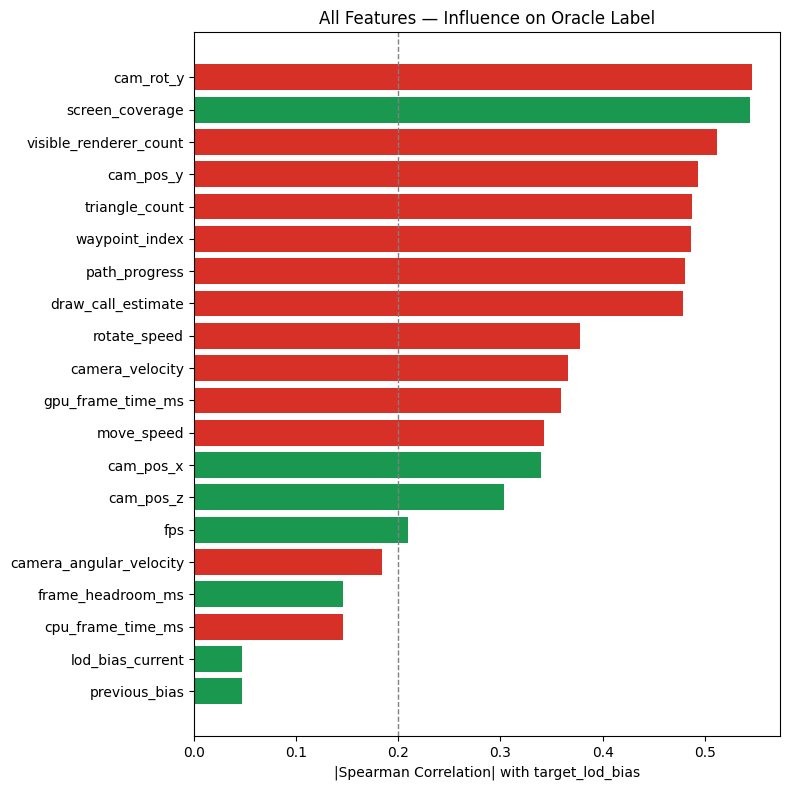

  cam_rot_y                      -0.5464  (- bias)
  screen_coverage                +0.5448  (+ bias)
  visible_renderer_count         -0.5122  (- bias)
  cam_pos_y                      -0.4934  (- bias)
  triangle_count                 -0.4875  (- bias)
  waypoint_index                 -0.4865  (- bias)
  path_progress                  -0.4807  (- bias)
  draw_call_estimate             -0.4787  (- bias)
  rotate_speed                   -0.3783  (- bias)
  camera_velocity                -0.3658  (- bias)
  gpu_frame_time_ms              -0.3589  (- bias)
  move_speed                     -0.3430  (- bias)
  cam_pos_x                      +0.3394  (+ bias)
  cam_pos_z                      +0.3030  (+ bias)
  fps                            +0.2094  (+ bias)
  camera_angular_velocity        -0.1841  (- bias)
  cpu_frame_time_ms              -0.1463  (- bias)
  frame_headroom_ms              +0.1463  (+ bias)
  previous_bias                  +0.0471  (+ bias)
  lod_bias_current             

In [ ]:
ALL_FEATURES = [
    'cpu_frame_time_ms', 'gpu_frame_time_ms', 'triangle_count',
    'camera_velocity', 'camera_angular_velocity', 'visible_renderer_count',
    'draw_call_estimate', 'frame_headroom_ms', 'screen_coverage',
    'lod_bias_current', 'fps', 'previous_bias',
    'cam_pos_x', 'cam_pos_y', 'cam_pos_z', 'cam_rot_y',
    'path_progress', 'waypoint_index', 'move_speed', 'rotate_speed'
]

corr = df[ALL_FEATURES + [TARGET_COL]].corr(method='spearman')[TARGET_COL].drop(TARGET_COL)
corr_sorted = corr.abs().sort_values(ascending=True)
colors = ['#d73027' if corr[f] < 0 else '#1a9850' for f in corr_sorted.index]

plt.figure(figsize=(8, 8))
plt.barh(corr_sorted.index, corr_sorted.values, color=colors)
plt.axvline(x=0.2, color='gray', linestyle='--', linewidth=1)
plt.xlabel('|Spearman Correlation| with target_lod_bias')
plt.title('All Features — Influence on Oracle Label')
plt.tight_layout()
plt.savefig('feature_influence_all.png', dpi=150)
plt.show()

for f in corr.abs().sort_values(ascending=False).index:
    direction = "+ bias" if corr[f] > 0 else "- bias"
    print(f"  {f:<30} {corr[f]:+.4f}  ({direction})")

In [ ]:
# Drop rows with NaN in features or target
df = df.dropna(subset=FEATURE_COLS + [TARGET_COL])
print(f'Rows after dropna: {len(df)}')

X     = df[FEATURE_COLS].values.astype(np.float32)
y_raw = df[TARGET_COL].values.astype(np.float32)

#  Label diagnostic
print(f'\nRaw target_lod_bias stats:')
print(f'  min={y_raw.min():.4f}  max={y_raw.max():.4f}  mean={y_raw.mean():.4f}  std={y_raw.std():.4f}')
print(f'  unique values: {len(np.unique(y_raw.round(4)))}')

# Normalize target to [0, 1] for Sigmoid output
y = (y_raw - BIAS_MIN) / (BIAS_MAX - BIAS_MIN)
print(f'\nNormalized target range: [{y.min():.4f}, {y.max():.4f}]')
print(f'Normalized target std:   {y.std():.4f}  (< 0.05 = collapse risk)')

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)
joblib.dump(scaler, SCALER_OUT)
assert os.path.exists(SCALER_OUT), f'Scaler not saved: {SCALER_OUT}'
print(f'Scaler saved to {SCALER_OUT}')

#  Feature variance diagnostic
print(f'\nFeature std after scaling (should all be ~1.0):')
for name, std in zip(FEATURE_COLS, X.std(axis=0)):
    flag = '  <-- LOW VARIANCE' if std < 0.5 else ''
    print(f'  {name:<30} std={std:.4f}{flag}')

# Split off 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)
# Split remaining into 80% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, shuffle=True
)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')


Rows after dropna: 135000

Raw target_lod_bias stats:
  min=0.2500  max=1.9991  mean=1.3710  std=0.5606
  unique values: 111

Normalized target range: [0.0000, 0.9995]
Normalized target std:   0.3204  (< 0.05 = collapse risk)
Scaler saved to /content/drive/MyDrive/Concordia/COMP432/Project/feature_scaler.pkl

Feature std after scaling (should all be ~1.0):
  cam_rot_y                      std=1.0000
  screen_coverage                std=1.0000
  visible_renderer_count         std=1.0000
  cam_pos_y                      std=1.0000
  triangle_count                 std=1.0000
  path_progress                  std=1.0000
  draw_call_estimate             std=1.0000
  camera_velocity                std=1.0000
  gpu_frame_time_ms              std=1.0000
  cam_pos_x                      std=1.0000
  cam_pos_z                      std=1.0000
  fps                            std=1.0000

Train: 86400 | Val: 21600 | Test: 27000


## 4. Dataset and DataLoader

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 169 | Val batches: 43


## 5. Model Definition
Architecture from project docs: Input -> 64 (ReLU) -> 32 (ReLU) -> 1 (Sigmoid)

In [ ]:
class LODPredictor(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, hidden3=16):
        super(LODPredictor, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.Linear(hidden3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

INPUT_DIM = X_train.shape[1]
model     = LODPredictor(INPUT_DIM, HIDDEN1, HIDDEN2, HIDDEN3).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params}')

LODPredictor(
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Total parameters: 3457


## 6. Training

In [ ]:
def diversity_loss(preds, weight=DIVERSITY_WEIGHT):
    """Penalize low batch prediction variance — prevents mean collapse."""
    pred_std = preds.std()
    if pred_std < 1e-6:
        return torch.tensor(0.0, device=preds.device)
    return -weight * pred_std

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.HuberLoss(delta=0.3)

BEST_MODEL_PATH = '/content/drive/MyDrive/Concordia/COMP432/Project/best_model.pt'

train_losses     = []
train_div_losses = []
val_losses       = []
best_val_loss    = float('inf')

for epoch in range(EPOCHS):
    # --- train ---
    model.train()
    batch_losses = []
    div_losses   = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)

        huber = criterion(preds, y_batch)
        div   = diversity_loss(preds)
        loss  = huber + div

        loss.backward()
        optimizer.step()
        batch_losses.append(huber.item())
        div_losses.append(abs(div.item()))

    train_loss = np.mean(batch_losses)
    train_div  = np.mean(div_losses)

    #  validate (no diversity term)
    model.eval()
    with torch.no_grad():
        val_batch_losses = []
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            val_batch_losses.append(criterion(preds, y_batch).item())
        val_loss = np.mean(val_batch_losses)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    train_losses.append(train_loss)
    train_div_losses.append(train_div)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Huber: {train_loss:.6f} | Div: {train_div:.6f} | Val: {val_loss:.6f}')

print('Training complete.')

# Reload best checkpoint
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'Loaded best model (val loss: {best_val_loss:.6f})')

# --- test ---
with torch.no_grad():
    X_test_t   = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_test_t   = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    test_preds = model(X_test_t)
    test_loss  = criterion(test_preds, y_test_t).item()

test_preds_bias  = test_preds.detach().cpu().numpy().flatten() * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

test_mae  = np.mean(np.abs(test_preds_bias - test_target_bias))
test_rmse = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'\nTest Huber (normalized): {test_loss:.6f}')
print(f'Test MAE   (bias units): {test_mae:.4f}')
print(f'Test RMSE  (bias units): {test_rmse:.4f}')
print(f'\nPredicted bias — min: {test_preds_bias.min():.4f}  max: {test_preds_bias.max():.4f}  std: {test_preds_bias.std():.4f}')
print(f'Oracle  bias  — min: {test_target_bias.min():.4f}  max: {test_target_bias.max():.4f}  std: {test_target_bias.std():.4f}')

Epoch  10/150 | Huber: 0.003101 | Div: 0.003186 | Val: 0.003201
Epoch  20/150 | Huber: 0.002341 | Div: 0.003224 | Val: 0.002509
Epoch  30/150 | Huber: 0.001968 | Div: 0.003239 | Val: 0.002161
Epoch  40/150 | Huber: 0.001709 | Div: 0.003252 | Val: 0.002001
Epoch  50/150 | Huber: 0.001470 | Div: 0.003258 | Val: 0.001506
Epoch  60/150 | Huber: 0.001395 | Div: 0.003265 | Val: 0.001532
Epoch  70/150 | Huber: 0.001311 | Div: 0.003264 | Val: 0.001356
Epoch  80/150 | Huber: 0.001222 | Div: 0.003267 | Val: 0.001379
Epoch  90/150 | Huber: 0.001180 | Div: 0.003271 | Val: 0.001165
Epoch 100/150 | Huber: 0.001124 | Div: 0.003271 | Val: 0.001083
Epoch 110/150 | Huber: 0.001071 | Div: 0.003274 | Val: 0.001111
Epoch 120/150 | Huber: 0.001063 | Div: 0.003273 | Val: 0.001274
Epoch 130/150 | Huber: 0.001054 | Div: 0.003273 | Val: 0.001171
Epoch 140/150 | Huber: 0.000983 | Div: 0.003273 | Val: 0.001020
Epoch 150/150 | Huber: 0.000941 | Div: 0.003273 | Val: 0.001035
Training complete.
Loaded best model (va

## 7. Loss Curves

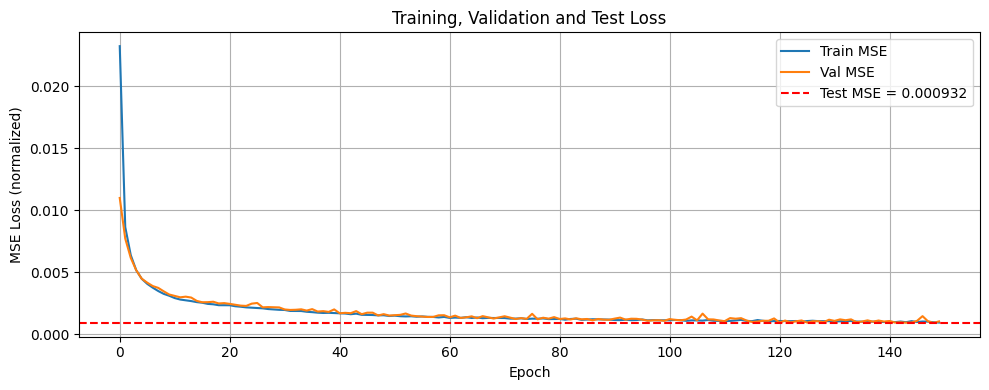

Final Train MSE : 0.000941
Final Val   MSE : 0.001035
Test        MSE : 0.000932
Test        MAE : 0.0390 (bias units)
Test        RMSE: 0.0781 (bias units)


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.axhline(y=test_loss, color='red', linestyle='--', label=f'Test MSE = {test_loss:.6f}')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Training, Validation and Test Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

print(f'Final Train MSE : {train_losses[-1]:.6f}')
print(f'Final Val   MSE : {val_losses[-1]:.6f}')
print(f'Test        MSE : {test_loss:.6f}')
print(f'Test        MAE : {test_mae:.4f} (bias units)')
print(f'Test        RMSE: {test_rmse:.4f} (bias units)')

## 8. Evaluation — Denormalized Predictions



Val  MAE: 0.0392 | Val  RMSE: 0.0774
Test MAE: 0.0390 | Test RMSE: 0.0781


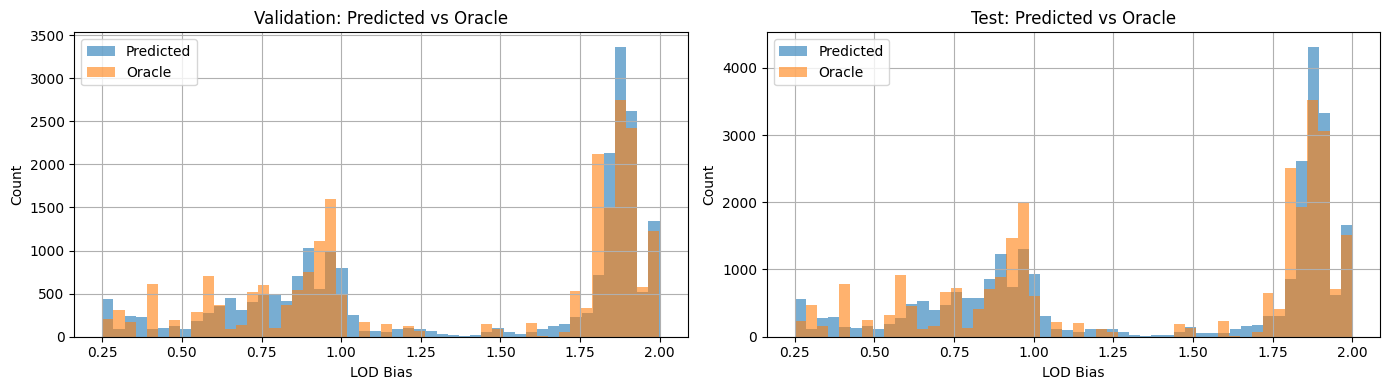

In [ ]:
model.eval()
with torch.no_grad():
    preds_norm      = model(X_val_t.to(DEVICE)).cpu().numpy().flatten()
    test_preds_norm = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()

# Denormalize
preds_bias       = preds_norm      * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_preds_bias  = test_preds_norm * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
target_bias      = y_val           * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test          * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

# Metrics
val_mae  = np.mean(np.abs(preds_bias  - target_bias))
val_rmse = np.sqrt(np.mean((preds_bias  - target_bias) ** 2))
t_mae    = np.mean(np.abs(test_preds_bias - test_target_bias))
t_rmse   = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'Val  MAE: {val_mae:.4f} | Val  RMSE: {val_rmse:.4f}')
print(f'Test MAE: {t_mae:.4f} | Test RMSE: {t_rmse:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[0].hist(target_bias, bins=50, alpha=0.6, label='Oracle')
axes[0].set_title('Validation: Predicted vs Oracle')
axes[0].set_xlabel('LOD Bias')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(test_preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[1].hist(test_target_bias, bins=50, alpha=0.6, label='Oracle')
axes[1].set_title('Test: Predicted vs Oracle')
axes[1].set_xlabel('LOD Bias')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=150)
plt.show()


checks which input features the trained model depends on. It shuffles one feature at a time and runs inference again. If the model’s loss increases, that feature is important; if not, it has little impact.

Baseline test loss: 0.000932

Permutation Importance (loss increase when feature is shuffled):
  cam_pos_x                      +0.051926
  path_progress                  +0.036672
  cam_pos_z                      +0.034768
  cam_rot_y                      +0.032515
  cam_pos_y                      +0.026139
  visible_renderer_count         +0.024596
  screen_coverage                +0.011009
  camera_velocity                +0.005494
  draw_call_estimate             +0.003634
  triangle_count                 +0.003216
  gpu_frame_time_ms              +0.002940
  fps                            +0.000004  <-- USELESS


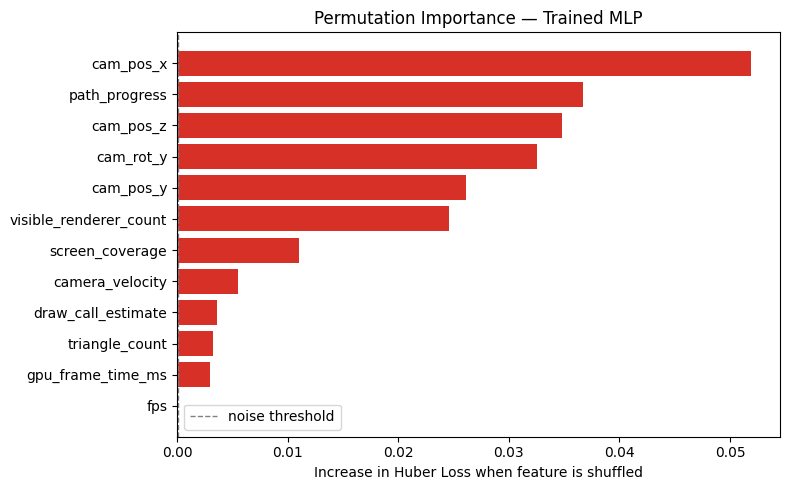

In [ ]:
# Permutation Importance   which features actually matter to the trained model
import numpy as np
import matplotlib.pyplot as plt

model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)

with torch.no_grad():
    baseline_loss = criterion(model(X_test_t), y_test_t).item()

importance = {}
for i, name in enumerate(FEATURE_COLS):
    X_perm = X_test.copy()
    np.random.shuffle(X_perm[:, i])        # shuffle one column, leave rest intact
    X_perm_t = torch.tensor(X_perm, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        perm_loss = criterion(model(X_perm_t), y_test_t).item()
    importance[name] = perm_loss - baseline_loss  # higher = more important

importance_sorted = dict(sorted(importance.items(), key=lambda x: x[1]))

print(f"Baseline test loss: {baseline_loss:.6f}")
print(f"\nPermutation Importance (loss increase when feature is shuffled):")
for name, delta in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    flag = "  <-- USELESS" if delta < 0.0001 else ""
    print(f"  {name:<30} +{delta:.6f}{flag}")

# Plot
colors = ['#d73027' if v > 0.001 else '#999999' for v in importance_sorted.values()]
plt.figure(figsize=(8, 5))
plt.barh(list(importance_sorted.keys()), list(importance_sorted.values()), color=colors)
plt.axvline(x=0.0001, color='gray', linestyle='--', linewidth=1, label='noise threshold')
plt.xlabel('Increase in Huber Loss when feature is shuffled')
plt.title('Permutation Importance — Trained MLP')
plt.legend()
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150)
plt.show()

## 9. Export to ONNX for Unity Sentis

In [ ]:
!pip install onnxscript onnx

In [ ]:
model.eval()
model.cpu()

dummy_input = torch.zeros(1, INPUT_DIM, dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    MODEL_OUT,
    export_params=True,
    opset_version=15,
    input_names=['features'],
    output_names=['lod_bias_normalized'],
    dynamic_axes={
        'features':           {0: 'batch_size'},
        'lod_bias_normalized': {0: 'batch_size'}
    }
)

size_kb = os.path.getsize(MODEL_OUT) / 1024
print(f'ONNX model saved to {MODEL_OUT} ({size_kb:.1f} KB)')
print(f'Input dim: {INPUT_DIM} features')
print(f'Output: normalized bias in [0,1] -> denormalize with BIAS_MIN={BIAS_MIN}, BIAS_MAX={BIAS_MAX}')

/tmp/ipykernel_418/438338614.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0305 09:42:36.815000 418 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model saved to /content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp.onnx (2.2 KB)
Input dim: 12 features
Output: normalized bias in [0,1] -> denormalize with BIAS_MIN=0.25, BIAS_MAX=2.0


In [ ]:
import onnx

# Load the split model (needs both .onnx and .onnx.data in same folder)
model_onnx = onnx.load(MODEL_OUT, load_external_data=True)

# Save as single self-contained file - no external data
SINGLE_OUT = '/content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp_single.onnx'
onnx.save_model(
    model_onnx,
    SINGLE_OUT,
    save_as_external_data=False
)

import os
size_kb = os.path.getsize(SINGLE_OUT) / 1024
print(f'Saved single-file ONNX: {SINGLE_OUT} ({size_kb:.1f} KB)')

Saved single-file ONNX: /content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp_single.onnx (15.0 KB)


### 9b. Export Scaler Constants to JSON

In [ ]:
import json, joblib

scaler = joblib.load(SCALER_OUT)

constants = {
    'mean':          scaler.mean_.tolist(),
    'scale':         scaler.scale_.tolist(),
    'feature_names': FEATURE_COLS,
    'bias_min':      BIAS_MIN,
    'bias_max':      BIAS_MAX
}

SCALER_JSON = '/content/drive/MyDrive/Concordia/COMP432/Project/scaler_constants.json'
with open(SCALER_JSON, 'w') as f:
    json.dump(constants, f, indent=2)

print(f'Saved to {SCALER_JSON}')
print(json.dumps(constants, indent=2))

Saved to /content/drive/MyDrive/Concordia/COMP432/Project/scaler_constants.json
{
  "mean": [
    88.18394819539192,
    0.010823687427240119,
    8727.834133333334,
    4.454445369692202,
    349866.0124148148,
    4.456927220990145,
    2563.3854814814813,
    3.8261654804284926,
    3.770054661552994,
    10.419490312004765,
    2.7134554816351857,
    119.22984416474942
  ],
  "scale": [
    111.03608085295251,
    0.011215882007319176,
    7884.284028073361,
    2.518410798014822,
    252012.14573877203,
    3.469162708362356,
    1993.8791703008442,
    3.11777248509249,
    0.9880065983148854,
    23.821506733055426,
    27.976506468206463,
    69.82608771260018
  ],
  "feature_names": [
    "cam_rot_y",
    "screen_coverage",
    "visible_renderer_count",
    "cam_pos_y",
    "triangle_count",
    "path_progress",
    "draw_call_estimate",
    "camera_velocity",
    "gpu_frame_time_ms",
    "cam_pos_x",
    "cam_pos_z",
    "fps"
  ],
  "bias_min": 0.25,
  "bias_max": 2.0
}


## 10. Unity Sentis Integration Notes

In `NeuralLODController.cs`, denormalize the output:

```csharp
float normalizedBias = output[0];  // Sigmoid output in [0,1]
float targetBias = normalizedBias * (2.0f - 0.25f) + 0.25f;// BIAS_MIN = 0.25f, BIAS_MAX = 2.0f
```

Feature order for the input tensor must match `FEATURE_COLS` exactly:
```
0  cpu_frame_time_ms
1  gpu_frame_time_ms
2  triangle_count
3  camera_velocity
4  camera_angular_velocity
5  visible_renderer_count
6  draw_call_estimate
7  frame_headroom_ms
8  screen_coverage
9  lod_bias_current
```

Apply scaler mean/std from `feature_scaler.pkl` to each feature before inference:
```csharp
float[] scalerMean = { /* from scaler.mean_ */ };
float[] scalerStd  = { /* from scaler.scale_ */ };
for (int i = 0; i < features.Length; i++)
    features[i] = (features[i] - scalerMean[i]) / scalerStd[i];
```